<a href="https://colab.research.google.com/github/AdamaBaba/Project/blob/main/Gradient_Boosting_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt

#Install kagglehu
!pip install -q kagglehub

#download the dataset from kaggle
path = kagglehub.dataset_download("lburleigh/asap-2-0")

print("Dataset downloaded to:")
print(path)

#show the files in the kaggle asap_2.0 dataset
os.listdir(path)

#loading the dataset to google colab
df = pd.read_csv(os.path.join(path, "ASAP2_train_sourcetexts.csv"))
print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.columns)
print()
print(df.isnull().sum())
print()
print(df.duplicated().sum())

Using Colab cache for faster access to the 'asap-2-0' dataset.
Dataset downloaded to:
/kaggle/input/asap-2-0
               essay_id  score  \
0  AAAVUP14319000159574      4   
1  AAAVUP14319000159542      2   
2  AAAVUP14319000159461      3   
3  AAAVUP14319000159420      2   
4  AAAVUP14319000159419      2   

                                           full_text  \
0  The author suggests that studying Venus is wor...   
1  NASA is fighting to be alble to to go to Venus...   
2  "The Evening Star", is one of the brightest po...   
3  The author supports this idea because from rea...   
4  How the author supports this idea is that he s...   

                                          assignment      prompt_name  \
0  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
1  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
2  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
3  In "The Challenge of Exploring Venus," the aut...  Exp

In [11]:
columns_to_keep = [
    "essay_id",
    "score",
    "full_text",
    "assignment",
    "prompt_name"
]

df = df[columns_to_keep]

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.columns)
print()
print(df.isnull().sum())
print()
print(df.duplicated().sum())


df["full_text"] = df["full_text"].str.strip()
df["assignment"] = df["assignment"].str.strip()
df["prompt_name"] = df["prompt_name"].str.strip()

(df["full_text"] == "").sum()
df["score"].value_counts().sort_index()



               essay_id  score  \
0  AAAVUP14319000159574      4   
1  AAAVUP14319000159542      2   
2  AAAVUP14319000159461      3   
3  AAAVUP14319000159420      2   
4  AAAVUP14319000159419      2   

                                           full_text  \
0  The author suggests that studying Venus is wor...   
1  NASA is fighting to be alble to to go to Venus...   
2  "The Evening Star", is one of the brightest po...   
3  The author supports this idea because from rea...   
4  How the author supports this idea is that he s...   

                                          assignment      prompt_name  
0  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
1  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
2  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
3  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
4  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  

<class 'pandas.core.frame

,count
score,
1,1751
2,6847
3,9021
4,5553
5,1356
6,200


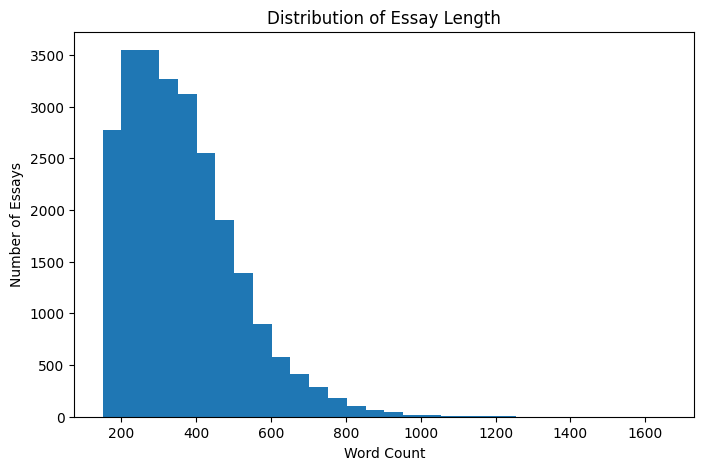

In [12]:
#Feature engineering
df["word_count"] = df["full_text"].apply(lambda x: len(x.split()))
df["word_count"].describe()


plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=30)
plt.xlabel("Word Count")
plt.ylabel("Number of Essays")
plt.title("Distribution of Essay Length")
plt.show()

--- Gradient Boosting Results ---
Mean Squared Error (MSE): 0.4703
R² Score: 0.5585

Feature Importances:
character_count        0.878235
sentence_count         0.047041
word_count             0.038964
unique_words           0.024094
avg_sentence_length    0.011666
dtype: float64


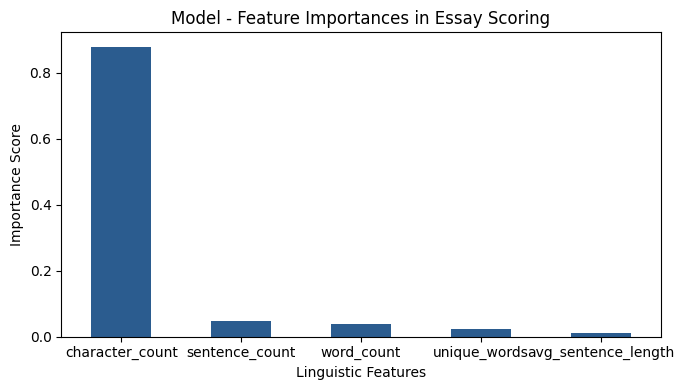

In [13]:
# CELL 4: BGRADIENT BOOSTING
# ==========================================
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize and train Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)

# 2. Predict on test set
y_pred_gb = gb_model.predict(X_test)

# 3. Evaluate performance
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("--- Gradient Boosting Results ---")
print(f"Mean Squared Error (MSE): {mse_gb:.4f}")
print(f"R² Score: {r2_gb:.4f}\n")

# 4. Feature Importance Analysis
importances = pd.Series(gb_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("Feature Importances:")
print(importances)

# 5. Plot Feature Importances
plt.figure(figsize=(7, 4))
importances.plot(kind='bar', color='#2b5c8f')
plt.title("Model - Feature Importances in Essay Scoring")
plt.xlabel("Linguistic Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
import re

# 1. Compute word count first
df["word_count"] = df["full_text"].apply(lambda x: len(x.split()))

# 2. Filter out essays with fewer than 20 words
df = df[df["word_count"] >= 20].copy()

# 3. Extract linguistic features
df["character_count"] = df["full_text"].apply(len)
df["sentence_count"] = df["full_text"].apply(lambda x: len(re.findall(r"[.!?]+", x)))

# Avoid division by zero if sentence count is 0
df["sentence_count"] = df["sentence_count"].replace(0, 1)
df["avg_sentence_length"] = df["word_count"] / df["sentence_count"]

df["unique_words"] = df["full_text"].apply(lambda x: len(set(x.lower().split())))

# 4. Save cleaned dataset
df.to_csv("cleaned_asap.csv", index=False)

print("Data cleaning & feature engineering complete! 'cleaned_asap.csv' saved.")
print(f"Final Data Shape: {df.shape}")
df[['word_count', 'character_count', 'sentence_count', 'avg_sentence_length', 'unique_words']].head()

Data cleaning & feature engineering complete! 'cleaned_asap.csv' saved.
Final Data Shape: (24728, 10)


,word_count,character_count,sentence_count,avg_sentence_length,unique_words
0,396,2329,17,23.294118,218
1,200,1019,12,16.666667,118
2,371,2141,31,11.967742,205
3,224,1251,10,22.400000,130
4,219,1230,7,31.285714,134


In [15]:
# GRADIENT BOOSTING MODEL
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define Features (X) and Target (y)
features = [
    "word_count",
    "character_count",
    "sentence_count",
    "avg_sentence_length",
    "unique_words"
]

X = df[features]
y = df["score"]

# 2. Split dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize and train Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

print("Training Gradient Boosting Model on Cleaned Dataset...")
gb_model.fit(X_train, y_train)
print("Training Complete!")

Training Gradient Boosting Model on Cleaned Dataset...
Training Complete!


In [16]:
# 1. Predict on test set
y_pred_gb = gb_model.predict(X_test)

# 2. Compute evaluation metrics
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("==========================================")
print("   GRADIENT BOOSTING RESULTS   ")
print("==========================================")
print(f"Mean Squared Error (MSE): {mse_gb:.4f}")
print(f"R² Score:                {r2_gb:.4f}")
print("==========================================")

# Display sample predictions vs actual scores
comparison_df = pd.DataFrame({
    'Actual Score': y_test.values[:10],
    'Predicted Score': y_pred_gb[:10]
})
print("\nSample Predictions (First 10 Essays):")
print(comparison_df.round(2))

   GRADIENT BOOSTING RESULTS   
Mean Squared Error (MSE): 0.4703
R² Score:                0.5585

Sample Predictions (First 10 Essays):
   Actual Score  Predicted Score
0             3             3.60
1             2             2.42
2             2             2.37
3             3             3.95
4             2             1.83
5             4             3.51
6             1             3.45
7             2             1.90
8             3             3.75
9             5             4.78


Feature Importance Rankings:
character_count        0.878235
sentence_count         0.047041
word_count             0.038964
unique_words           0.024094
avg_sentence_length    0.011666
dtype: float64


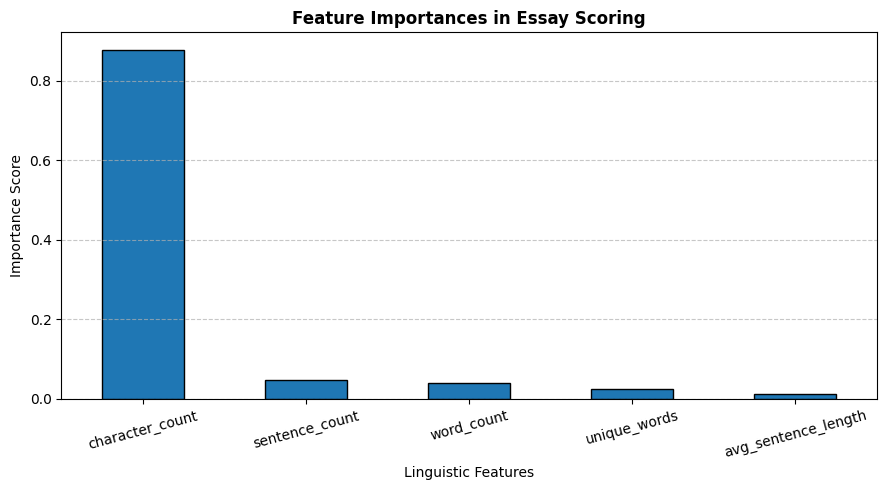

In [17]:
# 1. Extract feature importances
importances = pd.Series(gb_model.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

print("Feature Importance Rankings:")
print(importances)

# 2. Plot Feature Importance Bar Chart
plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='#1f77b4', edgecolor='black')
plt.title("Feature Importances in Essay Scoring", fontsize=12, fontweight='bold')
plt.xlabel("Linguistic Features", fontsize=10)
plt.ylabel("Importance Score", fontsize=10)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()